In [81]:
import os
import pandas as pd
import datetime as dt
from tqdm import tqdm
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('seaborn-v0_8-darkgrid')

In [82]:
metadata = pd.read_csv("data/STAR_1k_metadata.csv", index_col=0)
metadata["star_start_timestamp"] = pd.to_datetime(metadata["star_start_time"]).apply(lambda x: int(x.timestamp()))
metadata["star_end_timestamp"] = pd.to_datetime(metadata["star_end_time"]).apply(lambda x: int(x.timestamp()))
metadata["star [s]"] = metadata["star_end_timestamp"] - metadata["star_start_timestamp"]
metadata["fastq_filesize_[GiB]"] = metadata["fastq_filesize_bytes"] / 1024 ** 3
metadata["fastq_filesize_[GiB]"] = metadata["fastq_filesize_[GiB]"].round(1)

In [83]:
def parse_log_progress_out_to_df(dir_path, file_name):
    srr_id = file_name.split("_")[0]

    with open(os.path.join(dir_path, file_name), "r") as file:
        lines = file.readlines()[2:-1]  # Skip two-line header and "ALL DONE!" and the end

    # Parse progress lines to list
    for i, line in enumerate(lines):
        date_string = "2024 " + line[:15]
        timestamp = pd.to_datetime(date_string, format='%Y %b %d %H:%M:%S').timestamp()

        line = str(int(timestamp)) + line[15:]
        line = ','.join(filter(None, line.split(' '))).rstrip('\n')
        lines[i] = line

    # Create DataFrame from list
    headers = ["Time", "Speed M/hr", "Read number", "Read length", "Mapped unique %", "Mapped length", "Mapped MMrate","Mapped multi", "Unmapped multi+", "Unmapped MM", "Unmapped short", "Unmapped other"]
    df_progress = pd.read_csv(StringIO('\n'.join(lines)), names=headers)[["Time", "Speed M/hr", "Read number", "Mapped unique %"]]  # NOQA
    df_progress["Mapped unique %"] = df_progress["Mapped unique %"].apply(lambda x: x.replace('%', '')).astype(float)

    # Add start and end progress line
    srr_id_metadata = metadata.loc[metadata['SRR_id'] == srr_id]
    start_row = pd.DataFrame({'Time': srr_id_metadata["star_start_timestamp"], 'Speed M/hr': pd.NA, "Read number": 0, "Mapped unique %": pd.NA})
    end_row = pd.DataFrame({'Time': srr_id_metadata["star_end_timestamp"], 'Speed M/hr': pd.NA, "Read number": srr_id_metadata["n_spots"], "Mapped unique %": srr_id_metadata["STAR_mapping_rate [%]"].round(1)})
    return pd.concat([start_row, df_progress, end_row]).reset_index(drop=True)

### Finding ids for early stopping

In [84]:
dir_path = "data/log_progress"

es_data = []
mr_data = []

for file_name in tqdm(os.listdir(dir_path)):
    df = parse_log_progress_out_to_df(dir_path, file_name)
    if len(df) == 0:
        continue

    srr_id = file_name.split("_")[0]
    mr_data.append((srr_id, df["Mapped unique %"].min(), df["Mapped unique %"].max(), df.iloc[-1]["Time"] - df["Time"].min()))

    n_spots = df["Read number"][len(df) - 1]

    df_10up = df[df["Read number"] > 0.1 * n_spots]
    df_10up = df_10up.reset_index(drop=True)
    if any(df_10up["Mapped unique %"] < 30):
        es_data.append((srr_id, df_10up.iloc[-1]["Time"] - df_10up[df_10up["Mapped unique %"] < 30].iloc[0]["Time"]))


100%|██████████| 1000/1000 [00:15<00:00, 65.32it/s]


In [85]:
df_mr = pd.DataFrame(mr_data, columns=["SRR_id", "min_mr [%]", "max_mr [%]", "time [s]"]).sort_values("min_mr [%]")

df_es = pd.DataFrame(es_data, columns=["SRR_id", "wasted_time [s]"])
df_es = df_es.merge(right=metadata[["SRR_id", "star [s]", "fastq_filesize_[GiB]"]], how="inner", on="SRR_id").sort_values("fastq_filesize_[GiB]")

In [86]:
df_mr["time_cumsum"] = df_mr["time [s]"].cumsum()
df_mr["time_cumsum_prc"] = (df_mr["time_cumsum"] / df_mr["time_cumsum"].max() * 100).round(2)

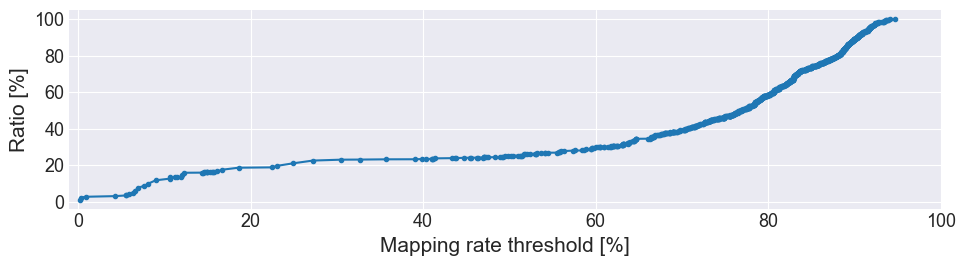

In [87]:
plt.figure(figsize=(10, 3))
plt.ylabel('Ratio [%]', fontsize=15)
plt.xlabel('Mapping rate threshold [%]', fontsize=15)
plt.xticks([0,20,40,60,80,100], fontsize=13)
plt.yticks([0,20,40,60,80,100], fontsize=13)
plt.xlim(-1, 100)
# plt.title('Total compute time spent on alignment resulting in mapping rate below given threshold.', fontsize=15)
plt.plot(df_mr["min_mr [%]"], df_mr["time_cumsum_prc"], marker='o', linestyle='-', markersize=3)
plt.tight_layout()
plt.savefig("plots/cumulative_time_by_mr.pdf", bbox_inches='tight')

In [88]:
print(f"Number of files valid for early stopping: {len(df_es)}")
total_star_workload_time = metadata["star [s]"].sum()
total_wasted_time = df_es["wasted_time [s]"].sum()
prc_savings = (total_wasted_time / total_star_workload_time).round(4) * 100
print(f"Possible time save by early stopping feature: {prc_savings}%")

Number of files valid for early stopping: 38
Possible time save by early stopping feature: 19.59%


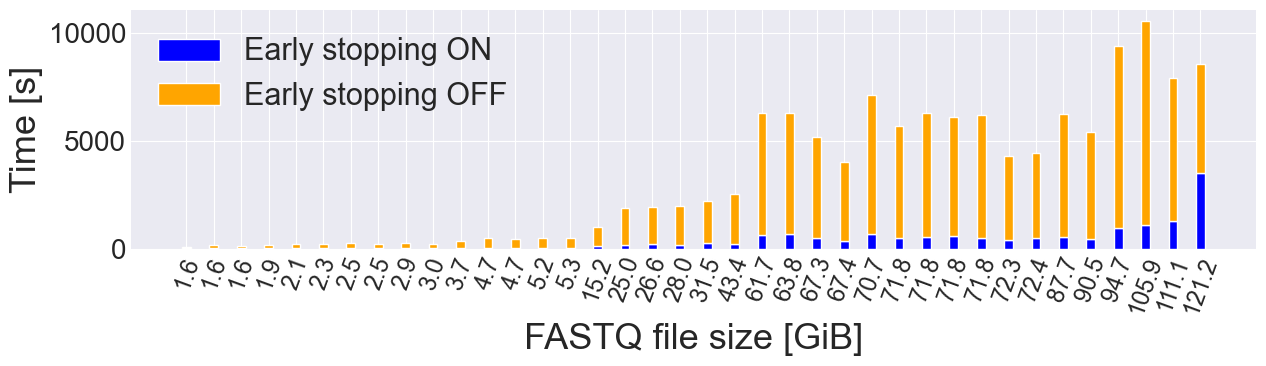

In [89]:
mpl.rcParams.update({'font.size': 18})
bar_width = 0.32

index = range(len(df_es))
plt.figure(figsize=(13, 4))

plt.bar(index, df_es['star [s]'] - df_es['wasted_time [s]'], bar_width, label='Early stopping ON', color='blue')
plt.bar(index, df_es['wasted_time [s]'], bar_width, bottom=df_es['star [s]'] - df_es['wasted_time [s]'],label='Early stopping OFF', color='orange')

# plt.title('Time savings by using early stopping (for inputs that result in low mapping rate).')
plt.xlabel('FASTQ file size [GiB]', fontsize=26)
plt.ylabel('Time [s]', fontsize=26)
plt.xticks(index, df_es['fastq_filesize_[GiB]'], rotation=70, fontsize=17)
plt.yticks(fontsize=20)
plt.legend(fontsize=22)
plt.tight_layout()
plt.savefig("plots/early_stopping.pdf", bbox_inches='tight')
plt.show()

In [90]:
### All identified ids fall below 30.5% mapping rate
x = set(metadata[metadata['SRR_id'].isin(df_es["SRR_id"])]["SRR_id"])
y = set(metadata[metadata["STAR_mapping_rate [%]"] < 30.5]["SRR_id"])
assert x == y

### Change in mapping rate during alignment

In [91]:
df_mr["mr_diff"] = df_mr["max_mr [%]"] - df_mr["min_mr [%]"]
df_mr = df_mr.merge(right=metadata[["SRR_id", "STAR_mapping_rate [%]", "fastq_filesize_[GiB]"]], how="inner", on="SRR_id")

#### Low mapping rate ids

In [92]:
df_mr[df_mr["STAR_mapping_rate [%]"] < 30.5].describe()

,min_mr [%],max_mr [%],time [s],time_cumsum,time_cumsum_prc,mr_diff,STAR_mapping_rate [%],fastq_filesize_[GiB]
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,12.160526,20.439474,3318.210526,70464.894737,12.559211,8.278947,14.445789,41.821053
std,6.419630,11.855653,3156.083119,33302.972857,5.936605,8.118053,5.741243,38.576096
min,0.200000,0.900000,117.000000,6275.000000,1.120000,0.000000,0.930000,1.600000
25%,7.175000,12.850000,318.000000,44421.250000,7.915000,3.500000,11.942500,3.175000
50%,12.150000,18.950000,2121.000000,85109.500000,15.165000,5.300000,14.775000,29.750000
75%,15.450000,22.375000,6162.750000,91650.000000,16.337500,9.325000,16.050000,71.800000
max,27.200000,58.600000,10534.000000,126092.000000,22.470000,33.700000,30.270000,121.200000


In [93]:
print(f'Mean mapping rate difference for low-mr ids: {df_mr[df_mr["STAR_mapping_rate [%]"] < 30.5]["mr_diff"].mean().round(2)}')
print(f'Standard dev of mapping rate difference for low-mr ids: {df_mr[df_mr["STAR_mapping_rate [%]"] < 30.5]["mr_diff"].std().round(2)}')

Mean mapping rate difference for low-mr ids: 8.28
Standard dev of mapping rate difference for low-mr ids: 8.12


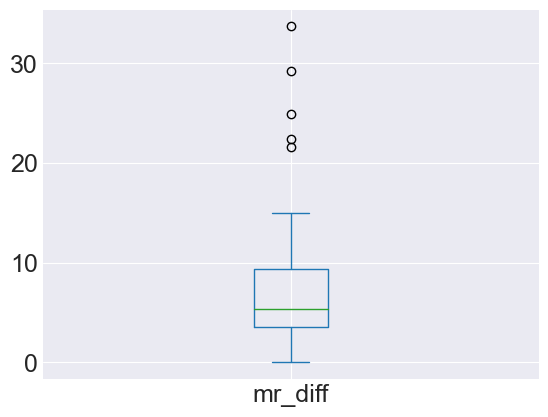

In [94]:
df_mr[df_mr["STAR_mapping_rate [%]"] < 30.5]["mr_diff"].plot.box();

#### High mapping-rate ids

In [95]:
df_mr[df_mr["STAR_mapping_rate [%]"] > 30.5].describe()

,min_mr [%],max_mr [%],time [s],time_cumsum,time_cumsum_prc,mr_diff,STAR_mapping_rate [%],fastq_filesize_[GiB]
count,962.000000,962.000000,962.000000,962.000000,962.000000,962.000000,962.000000,962.000000
mean,79.294699,79.572557,452.165281,352145.069647,62.762588,0.277859,79.416850,15.324740
std,11.166688,11.043231,517.557301,117774.053039,20.990686,0.911379,11.040679,15.066426
min,30.500000,30.600000,26.000000,128872.000000,22.970000,0.000000,30.580000,0.000000
25%,74.525000,74.700000,125.000000,256094.500000,45.645000,0.000000,74.682500,4.800000
50%,81.900000,82.300000,259.000000,359146.000000,64.010000,0.100000,82.150000,11.050000
75%,87.900000,88.200000,588.750000,447016.250000,79.667500,0.200000,87.952500,20.175000
max,94.700000,96.300000,5145.000000,561075.000000,100.000000,16.100000,94.750000,145.400000


In [96]:
print(f'Mean mapping rate difference for high-mr ids: {df_mr[df_mr["STAR_mapping_rate [%]"] > 30.5]["mr_diff"].mean().round(2)}')
print(f'Standard dev of mapping rate difference for high-mr ids: {df_mr[df_mr["STAR_mapping_rate [%]"] > 30.5]["mr_diff"].std().round(2)}')

Mean mapping rate difference for high-mr ids: 0.28
Standard dev of mapping rate difference for high-mr ids: 0.91


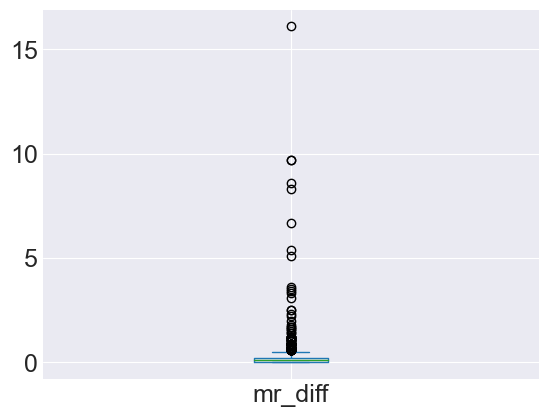

In [97]:
df_mr[df_mr["STAR_mapping_rate [%]"] > 30.5]["mr_diff"].plot.box();